# Pipeline Parallelism Step by Step

## Splitting a Model Across Devices by Layers

**Scenario**: A biotech startup trains a deep MLP to predict protein stability from sequence features. The model has so many layers that even with FSDP, each device's batch becomes too small for efficient utilization. **Pipeline Parallelism (PP)** solves this by **splitting the model across layers** — each device runs a different subset of layers.

This notebook builds up pipeline parallelism piece by piece:

1. **Why pipeline parallelism?** — when data parallelism runs out of steam
2. **Splitting layers across devices** — the stage concept
3. **The pipeline bubble** — idle time from sequential dependencies
4. **Micro-batching** — keeping all devices busy
5. **`ppermute`** — ring communication between stages
6. **Single pipeline step** — processing one micro-batch through stages
7. **Full pipeline execution** — scanning over micro-batches
8. **Parameter sharding** — `stack_params` / `unstack_params` for model-axis annotation
9. **Model parallelism wrapper** — making sharding transparent to modules
10. **Input/output masking** — first and last device handle embedding & classification
11. **Full PP training** — putting it all together

Based on the [UvA DLC Pipeline Parallelism tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/scaling/JAX/pipeline_parallel_simple.html).

---

## 1 — Setup

In [1]:
import os

N_DEVICES = 8
os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={N_DEVICES}"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [2]:
import functools
import warnings
from dataclasses import dataclass
from pprint import pprint
from typing import Any, Callable, Dict, Sequence, Tuple

import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optax
from flax.core.frozen_dict import FrozenDict
from flax.training import train_state
from jax import lax, random
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, NamedSharding
from jax.sharding import PartitionSpec as P
from ml_collections import ConfigDict

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams["font.family"] = "DejaVu Sans"

# Type aliases
PyTree = Any
Parameter = Any
Metrics = Dict[str, Tuple[jax.Array, jax.Array]]

print(f"JAX devices: {jax.device_count()} ({jax.devices()[0].platform})")

JAX devices: 8 (cpu)


/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_53722/3101288146.py:17: DeprecationWarning: jax.experimental.shard_map is deprecated in v0.8.0. Used jax.shard_map instead.
  from jax.experimental.shard_map import shard_map


---

## 2 — Why Pipeline Parallelism?

Recall how parallelism strategies differ:

| Strategy | What is split | Communication | Memory saving |
|---|---|---|---|
| **Data Parallel (DP)** | Batch | Gradient sync (all-reduce) | None — full model on every device |
| **FSDP** | Batch + Parameters | Gather/scatter per layer | Parameters split across devices |
| **Pipeline Parallel (PP)** | Model layers | Activations between stages | Each device holds only its layers |

As models grow deeper, even FSDP hits a wall: the per-device batch must shrink to fit memory, and small batches underutilize accelerators. PP takes a different approach — instead of replicating the full model, it **splits the model by layers** and assigns each chunk (a "stage") to a different device.

Consider a model with 8 layers and 4 devices:

```
Device 0: Layers 0-1  (Stage 0)
Device 1: Layers 2-3  (Stage 1)
Device 2: Layers 4-5  (Stage 2)
Device 3: Layers 6-7  (Stage 3)
```

Data flows through Stage 0 → Stage 1 → Stage 2 → Stage 3 sequentially. Each device only needs memory for **its own layers** plus the activations passing through.

---

## 3 — The Pipeline Bubble Problem

The naive approach has a critical flaw: **most devices are idle most of the time**.

With a single batch flowing through 4 stages:

```
Time →    t0    t1    t2    t3    t4    t5    t6    t7
Device 0: [FWD]  ---   ---   ---  [BWD]  ---   ---   ---
Device 1:  ---  [FWD]  ---   ---   ---  [BWD]  ---   ---
Device 2:  ---   ---  [FWD]  ---   ---   ---  [BWD]  ---
Device 3:  ---   ---   ---  [FWD]  ---   ---   ---  [BWD]
```

Each device only computes during 2 out of 8 time steps — the rest is the **pipeline bubble** (idle time). With $S$ stages, utilization is only $\frac{1}{S}$ — a 4-stage pipeline wastes 75% of compute!

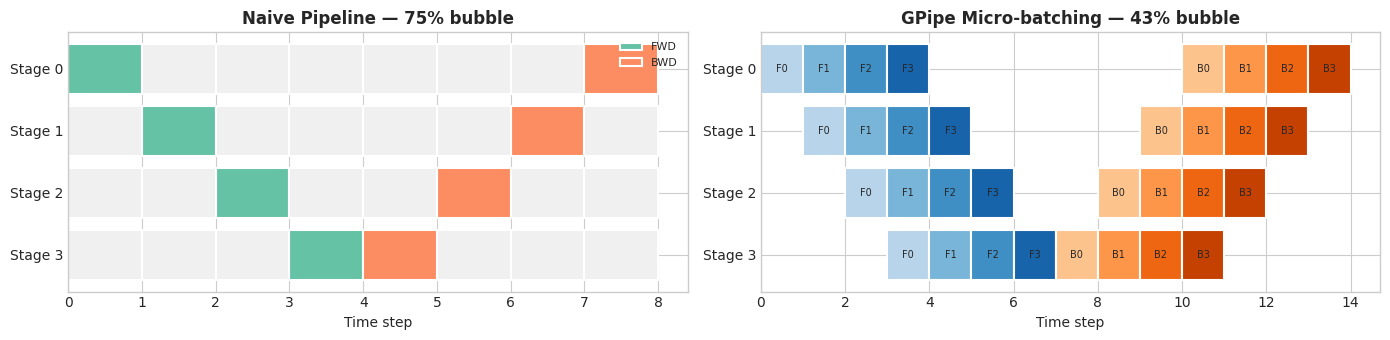

In [3]:
# Visualize the pipeline bubble
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

# Naive pipeline (no micro-batching)
ax = axes[0]
n_stages = 4
colors = plt.cm.Set2(np.linspace(0, 1, 8))
for s in range(n_stages):
    ax.barh(s, 1, left=s, color=colors[0], edgecolor="white", linewidth=1.5, label="FWD" if s == 0 else "")
    ax.barh(s, 1, left=2 * n_stages - 1 - s, color=colors[1], edgecolor="white", linewidth=1.5, label="BWD" if s == 0 else "")
for s in range(n_stages):
    for t in range(2 * n_stages):
        if t not in [s, 2 * n_stages - 1 - s]:
            ax.barh(s, 1, left=t, color="#f0f0f0", edgecolor="white", linewidth=1.5)
ax.set_yticks(range(n_stages))
ax.set_yticklabels([f"Stage {i}" for i in range(n_stages)])
ax.set_xlabel("Time step")
ax.set_title(f"Naive Pipeline — {75}% bubble", fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
ax.invert_yaxis()

# Micro-batched pipeline (GPipe)
ax = axes[1]
n_micro = 4
micro_colors = plt.cm.Blues(np.linspace(0.3, 0.8, n_micro))
bwd_colors = plt.cm.Oranges(np.linspace(0.3, 0.8, n_micro))

# Forward passes
for m in range(n_micro):
    for s in range(n_stages):
        t = m + s
        ax.barh(s, 1, left=t, color=micro_colors[m], edgecolor="white", linewidth=1.5)
        ax.text(t + 0.5, s, f"F{m}", ha="center", va="center", fontsize=7)

# Backward passes (reverse order)
fwd_end = n_micro + n_stages - 1
for m in range(n_micro):
    for s in range(n_stages - 1, -1, -1):
        t = fwd_end + m + (n_stages - 1 - s)
        ax.barh(s, 1, left=t, color=bwd_colors[m], edgecolor="white", linewidth=1.5)
        ax.text(t + 0.5, s, f"B{m}", ha="center", va="center", fontsize=7)

total_slots = n_stages * (fwd_end + n_micro + n_stages - 1)
active_slots = n_stages * 2 * n_micro
bubble_pct = (1 - active_slots / total_slots) * 100

ax.set_yticks(range(n_stages))
ax.set_yticklabels([f"Stage {i}" for i in range(n_stages)])
ax.set_xlabel("Time step")
ax.set_title(f"GPipe Micro-batching — {bubble_pct:.0f}% bubble", fontweight="bold")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

---

## 4 — Micro-batching: The GPipe Solution

The key insight from [GPipe (2019)](https://arxiv.org/abs/1811.06965): split each batch into $M$ **micro-batches** and feed them through the pipeline one after another. While Stage 1 processes micro-batch 0, Stage 0 can already start on micro-batch 1:

```
Time →      t0   t1   t2   t3   t4   t5   t6
Stage 0:   [μ0] [μ1] [μ2] [μ3]  ---  ---  ---
Stage 1:    --- [μ0] [μ1] [μ2] [μ3]  ---  ---
Stage 2:    ---  --- [μ0] [μ1] [μ2] [μ3]  ---
Stage 3:    ---  ---  --- [μ0] [μ1] [μ2] [μ3]
```

The bubble shrinks from $\frac{S-1}{S}$ to $\frac{S-1}{S + M - 1}$. With $M = 8$ micro-batches and $S = 4$ stages, the bubble is $\frac{3}{11} \approx 27\%$ instead of 75%.

**Trade-offs**:
- More micro-batches → smaller bubble, but more frequent inter-device communication
- Fewer micro-batches → less communication, but more idle time
- Each micro-batch is smaller → potential underutilization of matrix units

---

## 5 — `ppermute`: Ring Communication Between Stages

At each pipeline step, the output of stage $i$ needs to become the input of stage $i+1$. JAX provides `lax.ppermute` for this — a **permutation-based collective** that sends each device's data to a specified destination.

For a 4-stage pipeline, the permutation is a ring: $0 \to 1 \to 2 \to 3 \to 0$.

Let's see this in action:

In [ ]:
# Demonstrate ppermute with a simple ring
MODEL_AXIS = "model"
DATA_AXIS = "data"
MODEL_AXIS_SIZE = 4

device_array = np.array(jax.devices()).reshape(-1, MODEL_AXIS_SIZE)
mesh = Mesh(device_array, (DATA_AXIS, MODEL_AXIS))                          # Mesh (2, 4)

print(f"Device mesh: {device_array.shape} (data={device_array.shape[0]}, model={device_array.shape[1]})")
print(f"Mesh:\n{device_array}")

Device mesh: (2, 4) (data=2, model=4)
Mesh:
[[CpuDevice(id=0) CpuDevice(id=1) CpuDevice(id=2) CpuDevice(id=3)]
 [CpuDevice(id=4) CpuDevice(id=5) CpuDevice(id=6) CpuDevice(id=7)]]


In [5]:
# Each model-axis device starts with its index as data
# ppermute shifts everything one position to the right in the ring

def demo_ppermute(x):
    stage_index = lax.axis_index(MODEL_AXIS)
    num_stages = lax.psum(1, MODEL_AXIS)
    perm = [(i, (i + 1) % num_stages) for i in range(MODEL_AXIS_SIZE)]
    result = lax.ppermute(x, MODEL_AXIS, perm=perm)
    return result

ppermute_fn = jax.jit(
    shard_map(
        demo_ppermute,
        mesh,
        in_specs=P(DATA_AXIS, MODEL_AXIS),
        out_specs=P(DATA_AXIS, MODEL_AXIS),
    )
)

# Create data: each model-axis device gets its index
data = jnp.arange(N_DEVICES).reshape(device_array.shape).astype(jnp.float32)
data = jax.device_put(data, NamedSharding(mesh, P(DATA_AXIS, MODEL_AXIS)))

result = ppermute_fn(data)
print(f"Before ppermute: {data}")
print(f"After ppermute:  {result}")
print(f"\nPermutation: {[(i, (i + 1) % MODEL_AXIS_SIZE) for i in range(MODEL_AXIS_SIZE)]}")
print("Each value shifted one position right (3 wraps to 0)")

Before ppermute: [[0. 1. 2. 3.]
 [4. 5. 6. 7.]]
After ppermute:  [[3. 0. 1. 2.]
 [7. 4. 5. 6.]]

Permutation: [(0, 1), (1, 2), (2, 3), (3, 0)]
Each value shifted one position right (3 wraps to 0)


> **Why a ring?** Device $i$ sends its output to device $i+1$. The last device wraps to device 0, but this output gets discarded — it's just a side effect of the ring structure. The important flow is $0 \to 1 \to 2 \to 3$.

---

## 6 — Single Pipeline Step

Each pipeline step processes **one micro-batch** across all stages simultaneously. The logic per device:

1. **Select input**: Stage 0 takes the new micro-batch; other stages use the `state` received from the previous stage
2. **Compute**: Run the local layers on the input
3. **Collect output**: Only the last stage produces a real output; others output zeros
4. **Communicate**: `ppermute` sends each device's output to the next device in the ring

> **Why is `input` replicated across the model axis?** When `shard_map` is called with
> `in_specs=P(DATA_AXIS, None)` for the micro-batch, `None` on the model axis means
> **every stage receives a copy** of the same micro-batch. This is the simplest way to
> get the data onto stage 0. Stages 1–3 ignore it — `jnp.where(stage_index == 0, input, state)`
> ensures only stage 0 actually uses the micro-batch; all other stages work with the
> activation forwarded via `ppermute` from the previous stage.

```
                    ┌─────────────────────────┐
  micro-batch ─────►│  Stage 0 (if device 0)  │
  prev state ──────►│  or use state            │
                    │  → run local layers      │
                    │  → ppermute to next       │──► state for next device
                    │  → output if last stage   │──► output (or zeros)
                    └─────────────────────────┘
```

In [49]:
def execute_pipeline_step(
    module: nn.Module,
    state: jax.Array,                                                           # state (2, 16) (serial sended, 5 times)
    input: jax.Array,                                                           # input (2, 16) as nn.scan(in_axes=0)
    *args,
    model_axis_name: str,
    **kwargs,
) -> Tuple[jax.Array, jax.Array]:
    """Process one micro-batch through all pipeline stages.

    Args:
        module: The local layers for this stage.
        state: Activation received from previous stage (via ppermute).
        input: The micro-batch input (only used by stage 0).
        model_axis_name: Name of the model-parallel axis.

    Returns:
        (new_state, output): state for next iteration, output from last stage.
    """
    num_stages = jax.lax.psum(1, model_axis_name)
    stage_index = jax.lax.axis_index(model_axis_name)

    # Step 1: Stage 0 uses the micro-batch input; others use incoming state
    state = jnp.where(stage_index == 0, input, state)
     
    # Step 2: Run local layers
    state = module(state, *args, **kwargs)

    # Step 3: Only last stage produces real output
    output = jnp.where(
        stage_index == num_stages - 1,
        state,
        jnp.zeros_like(state),
    )

    # Step 4: Ring communication — send state to next device
    state = jax.lax.ppermute(
        state,
        model_axis_name,
        perm=[(i, (i + 1) % num_stages) for i in range(num_stages)],
    )

    return (state, output)
    # state (2, 16) is the carry for the next nn.scan iteration                         
    # output (2, 16) will be concatenated according to out_axes=0


print("execute_pipeline_step: one micro-batch through all stages")

execute_pipeline_step: one micro-batch through all stages


Let's trace through what happens step-by-step with 4 stages and 4 micro-batches. At each time step, we show what each device receives and sends:

| Time | Stage 0 receives | Stage 1 receives | Stage 2 receives | Stage 3 receives | Output |
|---|---|---|---|---|---|
| t=0 | μ0 (input) | zeros (no state yet) | zeros | zeros | zeros |
| t=1 | μ1 (input) | f₀(μ0) from stage 0 | zeros | zeros | zeros |
| t=2 | μ2 (input) | f₀(μ1) from stage 0 | f₁(f₀(μ0)) from stage 1 | zeros | zeros |
| t=3 | μ3 (input) | f₀(μ2) | f₁(f₀(μ1)) | f₂(f₁(f₀(μ0))) | **f₃(f₂(f₁(f₀(μ0))))** |
| t=4 | pad (zeros) | f₀(μ3) | f₁(f₀(μ2)) | f₂(f₁(f₀(μ1))) | **f(μ1)** |
| t=5 | pad (zeros) | zeros | f₁(f₀(μ3)) | f₂(f₁(f₀(μ2))) | **f(μ2)** |
| t=6 | pad (zeros) | zeros | zeros | f₂(f₁(f₀(μ3))) | **f(μ3)** |

The first $S-1 = 3$ steps are the **pipeline fill** (bubble) — outputs are all zeros. Real outputs arrive starting at $t = S - 1$.

---

## 7 — Full Pipeline Execution

The full pipeline orchestrates multiple micro-batch steps using `nn.scan`:

1. **Split** the batch into $M$ micro-batches
2. **Pad** with $S-1$ zero micro-batches (to flush the pipeline)
3. **Scan** over all $M + S - 1$ inputs, calling `execute_pipeline_step` each time
4. **Collect** the last $M$ outputs (discard the $S-1$ warmup outputs)
5. **Concatenate** micro-batch outputs back into a full batch

In [ ]:
@jax.named_scope("pipeline")
def execute_pipeline(
    module: nn.Module,                                                                          # module = stage
    x: jax.Array,
    *args,
    num_microbatches: int,
    model_axis_name: str,
    **kwargs,
) -> jax.Array:
    """Execute a full pipeline over a batch of data.

    Args:
        module: The local layers for this stage.
        x: Input batch [batch_size, ...]
        num_microbatches: Number of micro-batches to split into.
        model_axis_name: Name of the model-parallel axis.

    Returns:
        Output batch [batch_size, ...] from the last pipeline stage.
    """

    num_stages = jax.lax.psum(1, model_axis_name)
    batch_size = x.shape[0]
    assert (
        batch_size % num_microbatches == 0
    ), f"Batch size {batch_size} must be divisible by num_microbatches {num_microbatches}"
    microbatch_size = batch_size // num_microbatches                                            # microbatch_size = 2

    # Step 1: Split batch into micro-batches [M, microbatch_size, ...]                          # x (4, 16)       
    microbatches = jnp.reshape(x, (num_microbatches, microbatch_size, *x.shape[1:]))            # microbatches (2, 2, 16)

    # Step 2: Pad with S-1 zero micro-batches to flush the pipeline
    padding = jnp.zeros((num_stages - 1, *microbatches.shape[1:]), dtype=microbatches.dtype)    # padding (3, 2, 16)
    inputs = jnp.concatenate([microbatches, padding], axis=0)                                   # inputs (5, 2, 16)

    # Initialize state (activations passed between stages)
    state = jnp.zeros_like(microbatches[0])                                                     # state (2, 16)
    num_iterations = inputs.shape[0]                                                            # M + S - 1 # num_iterations = 5

    # Step 3: Scan over all inputs (*)
    _, outputs = nn.scan(                                       # outputs (5, 2, 16)
        functools.partial(
            execute_pipeline_step,
            *args,
            model_axis_name=model_axis_name,
            **kwargs,
        ),
        variable_broadcast={"params": True},                    # Same params every iteration (cf state['params'])
        split_rngs={"params": False, "dropout": True},          # Different dropout per micro-batch
        length=num_iterations,                                  # 5
        in_axes=0,                                              # Unstack inputs along first axis (loop over axis 0 of inputs)
        out_axes=0,                                             # Stack outputs along first axis
    )(module, state, inputs) # from execute_pipeline_step inputs | nn.scan (module, carry, x) -> (new_carry, y)
    # each 5 inputs chunk is managed by the 4 devices at the same time, along device axis (by the 8 devices exactly as 4 * 2 (data axis))

    print("outputs before concatenate")
    pprint(outputs)
    pprint(outputs[-num_microbatches:])
    # Step 4 & 5: Take last M outputs (skip S-1 warmup) and concatenate
    outputs = jnp.concatenate(outputs[-num_microbatches:], axis=0)     # <=== here *******
    print("outputs after concatenate")
    pprint(outputs)
    return outputs


print("execute_pipeline: full batch through micro-batched pipeline")

execute_pipeline: full batch through micro-batched pipeline


> **Why `variable_broadcast={'params': True}`?** Parameters don't change between micro-batch iterations (they're the same model weights). `nn.scan` would normally create a leading axis for scanned variables — broadcasting prevents this, keeping parameters fixed across the scan.
>
> **Why `split_rngs={'dropout': True}`?** Each micro-batch should get a different dropout mask. Splitting the RNG ensures randomness varies across micro-batches while keeping the same parameters.

(*) module is a Flax nn.Module instance. When nn.scan wraps it, Flax manages the params internally through that module object. You pass module as the first argument, and Flax knows to:

1. Extract the "params" collection from the module
2. Broadcast it (unchanged) to every scan iteration because of variable_broadcast={"params": True}
Make them available when execute_pipeline_step calls the module's forward pass
3. So the params never appear as an explicit argument in execute_pipeline_step — they're carried implicitly by the module object that Flax manages for you.

In [56]:
# Demo: run execute_pipeline with a simple Dense layer per stage
# Each stage applies Dense(hidden) → relu, so the full pipeline
# composes 4 stages: f₃(f₂(f₁(f₀(x))))

class DemoStage(nn.Module):
    """Minimal stage module: one Dense + relu."""
    features: int = 16

    @nn.compact
    def __call__(self, x: jax.Array) -> jax.Array:
        return nn.relu(nn.Dense(self.features)(x))


# Wrap execute_pipeline in a Flax module so nn.scan can manage variables
class DemoPipeline(nn.Module):
    @nn.compact
    def __call__(self, x):
        stage = DemoStage(features=x.shape[-1])
        return execute_pipeline(
            stage, x,
            num_microbatches=2,
            model_axis_name=MODEL_AXIS,
        )


# Run inside shard_map (check_rep=False needed because nn.scan
# carry and output have different replication patterns)
NUM_MICROBATCHES = 2
BATCH_SIZE = NUM_MICROBATCHES * 4  # 8 samples, 2 micro-batches of 4 (will be 2 in each device)
FEATURES = 16

demo_model = DemoPipeline()
dummy_x = jnp.ones((BATCH_SIZE, FEATURES))                              # dummy_x (8, 16)

# Step 1: discover partition specs via eval_shape (no arrays created)
init_pp_fn = shard_map(
    lambda x: demo_model.init(jax.random.PRNGKey(0), x),
    mesh,                                                               # Mesh (2, 4)
    in_specs=P(DATA_AXIS, None),                                        # in_specs (2, None)
    out_specs=P(),
    check_rep=False,
)
params_shapes = jax.eval_shape(init_pp_fn, dummy_x)
# print("params_shapes")
# pprint(params_shapes)
params_specs = nn.get_partition_spec(params_shapes)
# print("params_specs")
# pprint(params_specs)

# Step 2: actually create parameters with correct sharding
init_pp_fn = jax.jit(
    shard_map(
        lambda x: demo_model.init(jax.random.PRNGKey(0), x),
        mesh,
        in_specs=P(DATA_AXIS, None),
        out_specs=params_specs,
        check_rep=False,
    )
)
params = init_pp_fn(dummy_x)

# Forward pass
forward_fn = jax.jit(
    shard_map(
        lambda p, x: demo_model.apply(p, x),
        mesh,
        in_specs=(params_specs, P(DATA_AXIS, None)),
        out_specs=P(DATA_AXIS, None),
        check_rep=False,
    )
)

output = forward_fn(params, dummy_x)
print(f"Input shape:  {dummy_x.shape}")
print(f"Output shape: {output.shape}")
print(f"Output (first 2 samples, first 4 features):\n{output[:2, :4]}")
print(f"\nPipeline ran {MODEL_AXIS_SIZE} stages × {NUM_MICROBATCHES} micro-batches ✓")

outputs before concatenate
JitTracer(float32[5,2,16])
JitTracer(float32[2,2,16])
outputs after concatenate
JitTracer(float32[4,16])
outputs before concatenate
JitTracer(float32[5,2,16])
JitTracer(float32[2,2,16])
outputs after concatenate
JitTracer(float32[4,16])
outputs before concatenate
JitTracer(float32[5,2,16])
JitTracer(float32[2,2,16])
outputs after concatenate
JitTracer(float32[4,16])
Input shape:  (8, 16)
Output shape: (8, 16)
Output (first 2 samples, first 4 features):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Pipeline ran 4 stages × 2 micro-batches ✓


---

## 8 — The Stage Module: MLP Layers

Each pipeline stage runs a subset of the model's layers. We use a simple MLP with residual connections (similar to a Transformer block without attention). This is identical to what you'd use in a non-pipeline setting — **pipeline parallelism doesn't require model code changes**.

In [9]:
class MLPBlock(nn.Module):
    """Single MLP block with residual connection.

    Architecture: LayerNorm → Dense (expand) → SiLU → Dropout → Dense (project) + residual
    This mirrors a Transformer FFN block.
    """
    config: ConfigDict
    train: bool

    @nn.compact
    def __call__(self, x: jax.Array) -> jax.Array:
        input_features = x.shape[-1]
        residual = x

        x = nn.LayerNorm(dtype=self.config.dtype, name="pre_norm")(x)
        x = nn.Dense(
            features=self.config.hidden_size * self.config.mlp_expansion,
            dtype=self.config.dtype,
            name="input_dense",
        )(x)
        x = nn.silu(x)
        x = nn.Dropout(rate=self.config.dropout_rate, deterministic=not self.train)(x)
        x = nn.Dense(
            features=input_features,
            dtype=self.config.dtype,
            name="output_dense",
        )(x)

        return x + residual


print("MLPBlock: LayerNorm → Dense → SiLU → Dropout → Dense + residual")

MLPBlock: LayerNorm → Dense → SiLU → Dropout → Dense + residual


In [10]:
class MLPLayers(nn.Module):
    """Stack of MLP blocks using nn.scan for efficient compilation.

    nn.scan compiles the block once and loops — much faster than
    unrolling N separate block instances.
    """
    config: ConfigDict
    train: bool

    @nn.compact
    def __call__(self, x: jax.Array) -> jax.Array:
        block_class = MLPBlock
        if "MLP" in self.config.remat:
            block_class = nn.remat(block_class, prevent_cse=False)

        block = block_class(config=self.config, train=self.train, name="block")

        x, _ = nn.scan(
            lambda module, carry, _: (module(carry), ()),
            variable_axes={"params": 0},
            split_rngs={"params": True, "dropout": True},
            length=self.config.num_layers,
        )(block, x, ())

        return x


print("MLPLayers: scanned stack of MLPBlock (compiles once, loops N times)")

MLPLayers: scanned stack of MLPBlock (compiles once, loops N times)


> **`nn.scan` with `variable_axes={'params': 0}`** tells Flax that the parameters have an extra leading dimension — one set per layer. During execution, it slices along axis 0 to give each iteration its own parameters. This avoids compiling $N$ separate layer instances.

---

## 9 — Parameter Sharding: `stack_params` and `unstack_params`

In pipeline parallelism, different devices hold different layers. We need a way to:
1. **Annotate** which axis each parameter is sharded over (the "model" axis)
2. **Add** a dimension to parameters so each device holds its own slice
3. **Remove** that annotation when the module needs to use the parameters normally

Flax provides `nn.Partitioned` — a wrapper that stores a value plus its partition names. The two key functions:

- **`stack_params`**: Wraps each parameter in `nn.Partitioned` with a new model-axis dimension → tells JAX to shard along that axis
- **`unstack_params`**: Unwraps `nn.Partitioned`, squeezing out the model-axis dimension → the module sees normal arrays

In [11]:
def stack_params(
    params: PyTree,
    axis_name: str,
    axis: int = 0,
    mask_except: jax.Array | int | None = None,
) -> PyTree:
    """Add a sharding dimension to each parameter and wrap in nn.Partitioned.

    Args:
        params: Parameter pytree.
        axis_name: Name of the axis to shard over (e.g., 'model').
        axis: Position to insert the new dimension.
        mask_except: If set, zero out this param on all devices except this index.
                     Used for input/output layers that only live on one device.
    """
    def _stack(x: Parameter) -> Parameter:
        if isinstance(x, nn.Partitioned):
            value, names = x.value, x.names
        else:
            value, names = x, (None,) * x.ndim

        # Optionally zero out on all devices except mask_except
        if mask_except is not None:
            axis_index = jax.lax.axis_index(axis_name)
            value = jnp.where(axis_index == mask_except, value, 0.0)

        # Add a new dimension for the model axis
        value = jnp.expand_dims(value, axis)
        names = names[:axis] + (axis_name,) + names[axis:]

        return nn.Partitioned(value, names=names)

    return jax.tree.map(_stack, params, is_leaf=lambda x: isinstance(x, nn.Partitioned))


print("stack_params: wrap parameters with model-axis sharding annotation")

stack_params: wrap parameters with model-axis sharding annotation


In [12]:
def unstack_params(params: PyTree, axis_name: str) -> PyTree:
    """Remove sharding annotation, squeezing out the model-axis dimension.

    This is the inverse of stack_params — used when the module needs
    to see plain arrays without the extra dimension.
    """
    def _unstack(x: Parameter) -> Parameter:
        if isinstance(x, nn.Partitioned) and axis_name in x.names:
            value = x.value
            names = x.names
            axis_idx = names.index(axis_name)

            # Remove the model-axis dimension
            value = value.squeeze(axis_idx)
            names = names[:axis_idx] + names[axis_idx + 1:]

            # If no partition names remain, return plain array
            if all(n is None for n in names):
                return value
            else:
                return nn.Partitioned(value, names=names)
        else:
            return x

    return jax.tree.map(_unstack, params, is_leaf=lambda x: isinstance(x, nn.Partitioned))


print("unstack_params: remove model-axis annotation for module consumption")

unstack_params: remove model-axis annotation for module consumption


Let's test these on a simple parameter to see the effect:

In [13]:
# Demo: stack adds a dimension and annotation, unstack removes it
demo_params = {"weight": jnp.ones((3, 4)), "bias": jnp.zeros((4,))}


def demo_stack_unstack(params):
    stacked = stack_params(params, axis_name=MODEL_AXIS)
    unstacked = unstack_params(stacked, axis_name=MODEL_AXIS)
    return stacked, unstacked


demo_fn = shard_map(
    demo_stack_unstack,
    mesh,
    in_specs=P(),          # P() = replicated: full copy on every device
    out_specs=(P(), P()),  # P() = all replicas identical, shard_map returns one copy
    check_rep=False,       # skip verifying that all replicas are truly identical
)

stacked, unstacked = demo_fn(demo_params)

print("Original shapes:")
for k, v in demo_params.items():
    print(f"  {k}: {v.shape}")

print("\nAfter stack_params (added model-axis dim):")
for k, v in stacked.items():
    print(f"  {k}: value.shape={v.value.shape}, names={v.names}")

print("\nAfter unstack_params (removed model-axis dim):")
for k, v in unstacked.items():
    print(f"  {k}: shape={v.shape}")

Original shapes:
  weight: (3, 4)
  bias: (4,)

After stack_params (added model-axis dim):
  bias: value.shape=(1, 4), names=('model', None)
  weight: value.shape=(1, 3, 4), names=('model', None, None)

After unstack_params (removed model-axis dim):
  bias: shape=(4,)
  weight: shape=(3, 4)


> **`mask_except`**: For the input layer (only Stage 0 uses it) and output layers (only the last stage), we zero out parameters on all other devices. This prevents unnecessary gradient communication for parameters that only one device needs.

---

## 10 — Model Parallelism Wrapper

We need a Flax module that transparently:
1. **Folds** the RNG during init so each device gets different parameters
2. **Unstacks** parameters before the inner module sees them (via `nn.map_variables`)
3. **Stacks** parameters back after the module produces them

This is the glue between the sharding world (parameters have a model-axis dimension) and the module world (parameters are plain arrays).

In [14]:
# Helper: fold RNG so each model-axis device gets a different key
def fold_rng_over_axis(rng: jax.random.PRNGKey, axis_name: str | Sequence[str]) -> jax.random.PRNGKey:
    """Create a unique RNG per device along the given axis."""
    if isinstance(axis_name, str):
        axis_index = lax.axis_index(axis_name)
        return random.fold_in(rng, axis_index)
    else:
        for name in axis_name:
            rng = fold_rng_over_axis(rng, name)
        return rng


print("fold_rng_over_axis: unique RNG per device for different parameter init")

fold_rng_over_axis: unique RNG per device for different parameter init


In [15]:
class ModelParallelismWrapper(nn.Module):
    """Wraps a module with model-parallel parameter sharding.

    During init: folds RNG so each device initializes different params.
    During forward: unstacks params (removes model-axis dim) before
    the inner module, stacks them back after.
    """
    model_axis_name: str
    module_fn: Callable[..., nn.Module]
    mask_except_model_idx: int | None = None
    split_rngs: bool = True
    module_kwargs: FrozenDict[str, Any] = FrozenDict({})

    @nn.compact
    def __call__(self, *args, **kwargs):
        # During init: fold RNG so each model-axis device gets unique params
        if self.is_initializing() and self.split_rngs:
            self.scope.rngs["params"] = self.scope.rngs["params"].replace(
                rng=fold_rng_over_axis(
                    self.scope.rngs["params"].rng, self.model_axis_name
                )
            )

        # nn.map_variables transforms params on the way in and out:
        #   trans_in_fn (unstack): remove model-axis dim before module sees params
        #   trans_out_fn (stack): add model-axis dim after module produces params
        module = nn.map_variables(
            target=functools.partial(
                self.module_fn,
                name="sharded",
                **self.module_kwargs,
            ),
            trans_in_fn=functools.partial(
                unstack_params, axis_name=self.model_axis_name
            ),
            trans_out_fn=functools.partial(
                stack_params,
                axis_name=self.model_axis_name,
                mask_except=self.mask_except_model_idx,
            ),
            mapped_collections="params",
            mutable=True,
        )()

        return module(*args, **kwargs)


print("ModelParallelismWrapper: transparent sharding for any Flax module")

ModelParallelismWrapper: transparent sharding for any Flax module


> **How `nn.map_variables` works here:**
>
> When the inner module reads parameters:
> `stored (stacked with model-axis dim)` → `trans_in_fn (unstack)` → `module sees normal arrays`
>
> When the inner module writes/creates parameters:
> `module produces normal arrays` → `trans_out_fn (stack)` → `stored (stacked with model-axis dim)`
>
> The inner module never knows it's running in a pipeline — it just sees regular parameters.

---

## 11 — The PipelineModule

A thin wrapper that packages `execute_pipeline` as a Flax module:

In [16]:
class PipelineModule(nn.Module):
    """Flax module wrapping execute_pipeline."""
    model_axis_name: str
    num_microbatches: int
    module_fn: Callable[..., nn.Module]

    @nn.compact
    def __call__(self, *args, **kwargs):
        module = self.module_fn()
        return execute_pipeline(
            module,
            *args,
            **kwargs,
            num_microbatches=self.num_microbatches,
            model_axis_name=self.model_axis_name,
        )


print("PipelineModule: Flax wrapper around execute_pipeline")

PipelineModule: Flax wrapper around execute_pipeline


---

## 12 — Input/Output Masking: The Full PP Classifier

A practical pipeline model has three parts:

1. **Input layer** (Dense projection) — only on **Stage 0** (first device)
2. **Pipeline stages** (MLP layers) — distributed across all devices
3. **Output layers** (LayerNorm + Dense classifier) — only on **Stage $S-1$** (last device)

The input and output layers are wrapped with `mask_except_model_idx` to zero out their parameters on devices that don't use them. This means:
- Only Stage 0's input layer has non-zero weights
- Only the last stage's output layers have non-zero weights
- Masked parameters produce zero gradients → no wasted communication

In [17]:
class PPClassifier(nn.Module):
    """Full pipeline-parallel classifier.

    Input Dense (stage 0 only) → Pipeline MLP stages → LayerNorm + Dense (last stage only)
    """
    config: ConfigDict
    pipeline_module_class: Callable[..., nn.Module] = PipelineModule

    @nn.compact
    def __call__(self, x: jax.Array, train: bool) -> jax.Array:
        # Input projection — only Stage 0 has non-zero weights
        x = ModelParallelismWrapper(
            module_fn=functools.partial(
                nn.Dense,
                features=self.config.hidden_size,
                dtype=self.config.dtype,
            ),
            model_axis_name=self.config.model_axis_name,
            mask_except_model_idx=0,  # Only device 0
            name="input_dense",
        )(x)

        # Pipeline: MLP layers distributed across stages
        stage_module_fn = functools.partial(
            MLPLayers, config=self.config, train=train, name="mlp_layers"
        )
        pipeline_module_fn = functools.partial(
            self.pipeline_module_class,
            model_axis_name=self.config.model_axis_name,
            num_microbatches=self.config.num_microbatches,
            module_fn=stage_module_fn,
        )
        x = ModelParallelismWrapper(
            module_fn=pipeline_module_fn,
            model_axis_name=self.config.model_axis_name,
            name="pipeline",
        )(x)

        # Output layers — only last stage has non-zero weights
        output_wrapper = functools.partial(
            ModelParallelismWrapper,
            model_axis_name=self.config.model_axis_name,
            mask_except_model_idx=self.config.model_axis_size - 1,  # Only last device
        )
        x = output_wrapper(
            module_fn=functools.partial(nn.LayerNorm, dtype=self.config.dtype),
            name="output_norm",
        )(x)
        x = output_wrapper(
            module_fn=functools.partial(
                nn.Dense, features=self.config.num_classes, dtype=self.config.dtype
            ),
            name="output_dense",
        )(x)

        x = x.astype(jnp.float32)
        return x


print("PPClassifier: input (stage 0) → pipeline → output (last stage)")

PPClassifier: input (stage 0) → pipeline → output (last stage)


---

## 13 — Configuration

We configure a model with 8 total layers split across 4 pipeline stages (2 layers per stage), processing 8 micro-batches per batch. The device mesh has shape `(data=2, model=4)` — 2 data-parallel replicas, each with a 4-stage pipeline.

In [18]:
# Data config
N_CLASSES = 10
INPUT_SIZE = 784
BATCH_SIZE = 128
HIDDEN_SIZE = 512
NUM_LAYERS = 8
NUM_MICROBATCHES = 8

data_config = ConfigDict(dict(
    batch_size=BATCH_SIZE,
    num_classes=N_CLASSES,
    input_size=INPUT_SIZE,
))

model_config = ConfigDict(dict(
    hidden_size=HIDDEN_SIZE,
    mlp_expansion=1,
    dropout_rate=0.1,
    num_layers=NUM_LAYERS,
    dtype=jnp.float32,
    num_classes=N_CLASSES,
    remat=(),
    data_axis_name=DATA_AXIS,
    model_axis_name=MODEL_AXIS,
    model_axis_size=MODEL_AXIS_SIZE,
    num_microbatches=NUM_MICROBATCHES,
))

# Each stage gets num_layers // model_axis_size layers
model_config.num_layers = model_config.num_layers // model_config.model_axis_size

optimizer_config = ConfigDict(dict(
    learning_rate=1e-3,
    num_minibatches=1,
))

config = ConfigDict(dict(
    model=model_config,
    optimizer=optimizer_config,
    data=data_config,
    data_axis_name=DATA_AXIS,
    model_axis_name=MODEL_AXIS,
    model_axis_size=MODEL_AXIS_SIZE,
    seed=42,
))

print(f"Total layers: {NUM_LAYERS}")
print(f"Pipeline stages: {MODEL_AXIS_SIZE}")
print(f"Layers per stage: {model_config.num_layers}")
print(f"Micro-batches: {NUM_MICROBATCHES}")
print(f"Device mesh: ({N_DEVICES // MODEL_AXIS_SIZE} data) × ({MODEL_AXIS_SIZE} model)")
print(f"Batch size per data-parallel replica: {BATCH_SIZE // (N_DEVICES // MODEL_AXIS_SIZE)}")
print(f"Micro-batch size: {BATCH_SIZE // (N_DEVICES // MODEL_AXIS_SIZE) // NUM_MICROBATCHES}")

Total layers: 8
Pipeline stages: 4
Layers per stage: 2
Micro-batches: 8
Device mesh: (2 data) × (4 model)
Batch size per data-parallel replica: 64
Micro-batch size: 8


---

## 14 — Training Utilities

These helpers are shared across parallelism strategies (same as in the FSDP notebook). They handle gradient sync, accumulation, and metric tracking.

In [19]:
@dataclass
class Batch:
    """Container for a mini-batch."""
    inputs: jax.Array
    labels: jax.Array

jax.tree_util.register_dataclass(Batch, data_fields=["inputs", "labels"], meta_fields=[])


class TrainState(train_state.TrainState):
    """Train state with RNG for dropout."""
    rng: jax.Array


print("Batch and TrainState defined")

Batch and TrainState defined


In [20]:
def sync_gradients(grads: PyTree, axis_names: Sequence[str]) -> PyTree:
    """Average gradients across axes. Sharded params (nn.Partitioned) only
    sync over axes they aren't already sharded on."""

    def sync_grad(g: Parameter) -> Parameter:
        if isinstance(g, nn.Partitioned):
            replication_axis_names = [
                name
                for name in axis_names
                if name not in jax.tree_util.tree_leaves(g.names)
            ]
            if len(replication_axis_names) == 0:
                return g
            else:
                return g.replace(
                    value=lax.pmean(g.value, axis_name=replication_axis_names)
                )
        else:
            return lax.pmean(g, axis_name=axis_names)

    return jax.tree.map(
        sync_grad, grads, is_leaf=lambda x: isinstance(x, nn.Partitioned)
    )


print("sync_gradients: average gradients across data+model axes")

sync_gradients: average gradients across data+model axes


In [21]:
def accumulate_gradients(
    state: TrainState,
    batch: Batch,
    rng: jax.Array,
    num_minibatches: int,
    loss_fn: Callable,
) -> Tuple[PyTree, Metrics]:
    """Accumulate gradients over minibatches using lax.scan."""
    batch_size = batch.inputs.shape[0]
    minibatch_size = batch_size // num_minibatches
    rngs = random.split(rng, num_minibatches)

    def _minibatch_step(carry, minibatch_idx):
        grad_acc, metric_acc = carry
        start = minibatch_idx * minibatch_size
        minibatch = Batch(
            inputs=lax.dynamic_slice_in_dim(batch.inputs, start, minibatch_size, axis=0),
            labels=lax.dynamic_slice_in_dim(batch.labels, start, minibatch_size, axis=0),
        )
        grads, metrics = jax.grad(loss_fn, has_aux=True)(
            state.params, state.apply_fn, minibatch, rngs[minibatch_idx]
        )
        grad_acc = jax.tree.map(jnp.add, grad_acc, grads)
        metric_acc = jax.tree.map(jnp.add, metric_acc, metrics)
        return (grad_acc, metric_acc), None

    init_grads = jax.tree.map(jnp.zeros_like, state.params)
    init_metrics = {
        "loss": (jnp.zeros(()), jnp.zeros(())),
        "accuracy": (jnp.zeros(()), jnp.zeros(())),
    }
    (grads, metrics), _ = lax.scan(
        _minibatch_step, (init_grads, init_metrics), jnp.arange(num_minibatches)
    )
    grads = jax.tree.map(lambda g: g / num_minibatches, grads)
    return grads, metrics


print("accumulate_gradients: gradient accumulation via lax.scan")

accumulate_gradients: gradient accumulation via lax.scan


In [22]:
def print_metrics(metrics: Metrics, title: str = "Metrics"):
    """Pretty-print aggregated metrics."""
    print(f"\n{title}:")
    for name, (total, count) in metrics.items():
        value = total / count if count > 0 else 0.0
        print(f"  {name}: {value:.4f}")


print("print_metrics: display loss and accuracy")

print_metrics: display loss and accuracy


---

## 15 — Loss Function (Pipeline-Aware)

The loss is only computed on the **last pipeline stage** — other stages produce zero outputs (by design in `execute_pipeline_step`). We mask the loss and metrics on all non-final devices to avoid counting garbage:

In [23]:
def loss_fn(
    params: PyTree, apply_fn: Any, batch: Batch, rng: jax.Array
) -> Tuple[jax.Array, Metrics]:
    """Cross-entropy loss, computed only on the last pipeline stage."""
    # Unique dropout RNG per device (both data and model axes)
    dropout_rng = fold_rng_over_axis(rng, (config.data_axis_name, config.model_axis_name))

    logits = apply_fn(
        {"params": params},
        batch.inputs,
        train=True,
        rngs={"dropout": dropout_rng},
    )

    loss = optax.softmax_cross_entropy_with_integer_labels(logits, batch.labels)
    correct_pred = jnp.equal(jnp.argmax(logits, axis=-1), batch.labels)
    batch_size = batch.inputs.shape[0]

    # Mask: only the last stage (model_idx == model_size - 1) has real outputs
    model_idx = jax.lax.axis_index(config.model_axis_name)
    model_size = jax.lax.psum(1, config.model_axis_name)
    loss = jnp.where(model_idx != model_size - 1, 0.0, loss)
    correct_pred = jnp.where(model_idx != model_size - 1, False, correct_pred)
    batch_size = jnp.where(model_idx != model_size - 1, 0, batch_size)

    step_metrics = {
        "loss": (loss.sum(), batch_size),
        "accuracy": (correct_pred.sum(), batch_size),
    }
    loss = loss.mean()
    return loss, step_metrics


print("loss_fn: cross-entropy masked to last pipeline stage only")

loss_fn: cross-entropy masked to last pipeline stage only


> **Why mask instead of computing loss only on the last device?** Inside `shard_map`, all devices run the same code. We can't conditionally skip computation, but we can zero out the values. The zero loss on non-final devices means their gradients flow through the pipeline backward pass correctly while not contributing to the metric aggregation.

---

## 16 — Training Step

The training step accumulates gradients, syncs them across **both** the data and model axes, applies the optimizer, and aggregates metrics:

In [24]:
def train_step_pp(
    state: TrainState,
    metrics: Metrics | None,
    batch: Batch,
) -> Tuple[TrainState, Metrics]:
    """Single pipeline-parallel training step."""
    rng, step_rng = jax.random.split(state.rng)

    # Accumulate gradients (supports gradient accumulation over minibatches)
    grads, step_metrics = accumulate_gradients(
        state,
        batch,
        step_rng,
        config.optimizer.num_minibatches,
        loss_fn=loss_fn,
    )

    # Sync gradients across all devices (data + model axes)
    with jax.named_scope("sync_gradients"):
        grads = sync_gradients(grads, (config.data_axis_name, config.model_axis_name))

    # Apply optimizer
    new_state = state.apply_gradients(grads=grads, rng=rng)

    # Sync metrics across all devices
    with jax.named_scope("sync_metrics"):
        step_metrics = jax.tree.map(
            lambda x: jax.lax.psum(
                x, axis_name=(config.data_axis_name, config.model_axis_name)
            ),
            step_metrics,
        )

    if metrics is None:
        metrics = step_metrics
    else:
        metrics = jax.tree.map(jnp.add, metrics, step_metrics)

    return new_state, metrics


print("train_step_pp: gradient accumulation → sync → optimizer → metrics")

train_step_pp: gradient accumulation → sync → optimizer → metrics


---

## 17 — Initialization (Two-Step Process)

Pipeline-parallel initialization uses the same two-step approach as FSDP:

1. **`jax.eval_shape`**: Run init without creating arrays to discover partition specs
2. **`jax.jit` + `shard_map`**: Actually create and distribute parameters

This avoids materializing a full-model copy on a single device.

In [25]:
# Create model and optimizer
model_pp = PPClassifier(config=model_config)
optimizer = optax.adamw(learning_rate=config.optimizer.learning_rate)

# Create synthetic data
rng = jax.random.PRNGKey(config.seed)
model_init_rng, data_inputs_rng, data_labels_rng = jax.random.split(rng, 3)

batch = Batch(
    inputs=jax.random.normal(data_inputs_rng, (config.data.batch_size, config.data.input_size)),
    labels=jax.random.randint(
        data_labels_rng, (config.data.batch_size,), 0, config.data.num_classes
    ),
)

print(f"Batch: inputs {batch.inputs.shape}, labels {batch.labels.shape}")
print(f"Model: PPClassifier with {NUM_LAYERS} total layers across {MODEL_AXIS_SIZE} stages")

Batch: inputs (128, 784), labels (128,)
Model: PPClassifier with 8 total layers across 4 stages


In [26]:
def init_fn(rng: jax.random.PRNGKey, x: jax.Array, model: nn.Module) -> TrainState:
    """Initialize model parameters and optimizer state."""
    init_rng, rng = jax.random.split(rng)
    variables = model.init({"params": init_rng}, x, train=False)
    params = variables.pop("params")
    state = TrainState.create(
        apply_fn=model.apply,
        params=params,
        tx=optimizer,
        rng=rng,
    )
    return state


# Step 1: Discover partition specs (no arrays created)
init_pp_fn = shard_map(
    functools.partial(init_fn, model=model_pp),
    mesh,
    in_specs=(P(), P(config.data_axis_name)),
    out_specs=P(),
    check_rep=False,
)
state_pp_shapes = jax.eval_shape(init_pp_fn, model_init_rng, batch.inputs)
state_pp_specs = nn.get_partition_spec(state_pp_shapes)

print("Partition specs discovered:")
pprint(state_pp_specs.params)

Partition specs discovered:
{'input_dense': {'sharded': {'bias': P('model', None),
                             'kernel': P('model', None, None)}},
 'output_dense': {'sharded': {'bias': P('model', None),
                              'kernel': P('model', None, None)}},
 'output_norm': {'sharded': {'bias': P('model', None),
                             'scale': P('model', None)}},
 'pipeline': {'sharded': {'mlp_layers': {'block': {'input_dense': {'bias': P('model', None, None),
                                                                   'kernel': P('model', None, None, None)},
                                                   'output_dense': {'bias': P('model', None, None),
                                                                    'kernel': P('model', None, None, None)},
                                                   'pre_norm': {'bias': P('model', None, None),
                                                                'scale': P('model', None, None)}}}}}}


The partition specs show:
- **Pipeline parameters** have `model` as their first axis (sharded across pipeline stages)
- **Input dense** has `model` axis with masking (only stage 0 is non-zero)
- **Output norm/dense** have `model` axis with masking (only last stage is non-zero)
- The `nn.scan` layer dimension appears as a second axis in pipeline parameters

In [27]:
# Step 2: Actually create and distribute parameters
init_pp_fn = jax.jit(
    shard_map(
        functools.partial(init_fn, model=model_pp),
        mesh,
        in_specs=(P(), P(config.data_axis_name)),
        out_specs=state_pp_specs,
        check_rep=False,
    ),
)
state_pp = init_pp_fn(model_init_rng, batch.inputs)

print("Parameters initialized and distributed across mesh")
print(f"\nParameter shapes:")
param_shapes = jax.tree.map(lambda x: x.shape, state_pp.params)
pprint(param_shapes)

Parameters initialized and distributed across mesh

Parameter shapes:
{'input_dense': {'sharded': {'bias': Partitioned(value=(4, 512),
                                                 names=('model', None),
                                                 mesh=None),
                             'kernel': Partitioned(value=(4, 784, 512),
                                                   names=('model', None, None),
                                                   mesh=None)}},
 'output_dense': {'sharded': {'bias': Partitioned(value=(4, 10),
                                                  names=('model', None),
                                                  mesh=None),
                              'kernel': Partitioned(value=(4, 512, 10),
                                                    names=('model', None, None),
                                                    mesh=None)}},
 'output_norm': {'sharded': {'bias': Partitioned(value=(4, 512),
                               

Let's verify that different pipeline stages have different parameters (thanks to RNG folding), and that masked parameters are zero on the correct devices:

In [28]:
# Verify: different stages have different pipeline params
pipeline_kernel = state_pp.params["pipeline"]["sharded"]["mlp_layers"]["block"]["input_dense"]["kernel"]
# nn.Partitioned wraps the value — unwrap it
if isinstance(pipeline_kernel, nn.Partitioned):
    pipeline_kernel = pipeline_kernel.value

print("Pipeline input_dense kernel — mean per stage (should differ):")
for stage in range(MODEL_AXIS_SIZE):
    stage_mean = pipeline_kernel[stage].mean()
    print(f"  Stage {stage}: mean = {stage_mean:.6f}")

print("\nInput dense kernel — sum per stage (only stage 0 should be non-zero):")
input_kernel = state_pp.params["input_dense"]["sharded"]["kernel"]
if isinstance(input_kernel, nn.Partitioned):
    input_kernel = input_kernel.value
for stage in range(MODEL_AXIS_SIZE):
    stage_sum = jnp.abs(input_kernel[stage]).sum()
    print(f"  Stage {stage}: |sum| = {stage_sum:.6f}{'  ← active' if stage == 0 else '  ← masked (zero)'}")

print("\nOutput dense kernel — sum per stage (only last stage should be non-zero):")
output_kernel = state_pp.params["output_dense"]["sharded"]["kernel"]
if isinstance(output_kernel, nn.Partitioned):
    output_kernel = output_kernel.value
for stage in range(MODEL_AXIS_SIZE):
    stage_sum = jnp.abs(output_kernel[stage]).sum()
    last = MODEL_AXIS_SIZE - 1
    print(f"  Stage {stage}: |sum| = {stage_sum:.6f}{'  ← active' if stage == last else '  ← masked (zero)'}")

Pipeline input_dense kernel — mean per stage (should differ):
  Stage 0: mean = 0.000058
  Stage 1: mean = 0.000005
  Stage 2: mean = 0.000074
  Stage 3: mean = -0.000094

Input dense kernel — sum per stage (only stage 0 should be non-zero):
  Stage 0: |sum| = 11788.041992  ← active
  Stage 1: |sum| = 0.000000  ← masked (zero)
  Stage 2: |sum| = 0.000000  ← masked (zero)
  Stage 3: |sum| = 0.000000  ← masked (zero)

Output dense kernel — sum per stage (only last stage should be non-zero):
  Stage 0: |sum| = 0.000000  ← masked (zero)
  Stage 1: |sum| = 0.000000  ← masked (zero)
  Stage 2: |sum| = 0.000000  ← masked (zero)
  Stage 3: |sum| = 185.845276  ← active


---

## 18 — Compile and Run Training

We JIT-compile the training step with `shard_map`, using `donate_argnames` to reuse memory buffers between steps.

In [29]:
# Compile training step
train_step_pp_fn = jax.jit(
    shard_map(
        train_step_pp,
        mesh,
        in_specs=(state_pp_specs, P(), P(config.data_axis_name)),
        out_specs=(state_pp_specs, P()),
        check_rep=False,
    ),
    donate_argnames=("state", "metrics"),
)

# Initialize metrics shape (need eval_shape first)
_, metric_shapes = jax.eval_shape(
    train_step_pp_fn,
    state_pp,
    None,
    batch,
)
metrics_pp = jax.tree.map(lambda x: jnp.zeros(x.shape, dtype=x.dtype), metric_shapes)

# Warmup step (triggers compilation)
state_pp, metrics_pp = train_step_pp_fn(state_pp, metrics_pp, batch)

print("Compilation complete. Running warmup step...")
print_metrics(metrics_pp, title="Warmup Metrics")

Compilation complete. Running warmup step...

Warmup Metrics:
  accuracy: 0.1328
  loss: 2.6077


In [30]:
# Training loop
NUM_STEPS = 15

print(f"Training for {NUM_STEPS} steps...")
for step in range(NUM_STEPS):
    state_pp, metrics_pp = train_step_pp_fn(state_pp, metrics_pp, batch)

# Final evaluation step (reset metrics for clean measurement)
final_metrics = jax.tree.map(lambda x: jnp.zeros(x.shape, dtype=x.dtype), metric_shapes)
state_pp, final_metrics = train_step_pp_fn(state_pp, final_metrics, batch)

print_metrics(final_metrics, title="Final Metrics — Pipeline Parallel")

Training for 15 steps...

Final Metrics — Pipeline Parallel:
  accuracy: 1.0000
  loss: 0.0002


The loss should be near zero and accuracy near 1.0 — we're overfitting a small random dataset on purpose to verify that all pipeline stages communicate correctly and gradients flow through the full pipeline.

---

## 19 — Visualizing the Pipeline

Let's visualize how micro-batches flow through our 4-stage pipeline with 8 micro-batches, showing both the bubble ratio and device utilization:

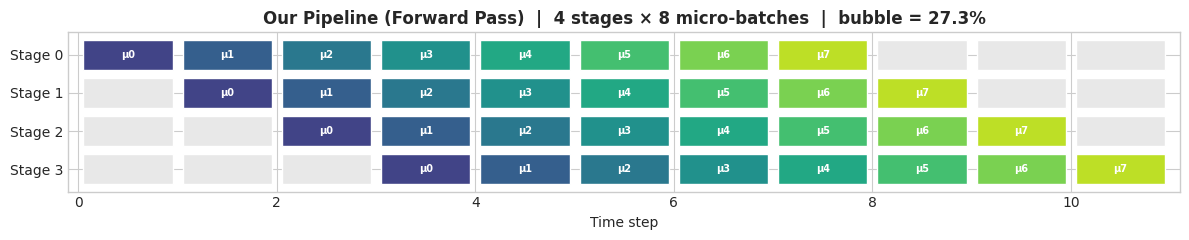

In [31]:
def plot_pipeline_schedule(n_stages, n_microbatches, title="Pipeline Schedule"):
    """Visualize the pipeline execution schedule."""
    total_steps = n_microbatches + n_stages - 1
    bubble_ratio = (n_stages - 1) / total_steps

    fig, ax = plt.subplots(figsize=(max(12, total_steps * 0.8), 2.5))

    cmap = plt.cm.viridis(np.linspace(0.2, 0.9, n_microbatches))

    for stage in range(n_stages):
        for t in range(total_steps):
            micro_idx = t - stage
            if 0 <= micro_idx < n_microbatches:
                ax.barh(stage, 0.9, left=t + 0.05, color=cmap[micro_idx],
                        edgecolor="white", linewidth=1)
                ax.text(t + 0.5, stage, f"μ{micro_idx}", ha="center", va="center",
                        fontsize=7, color="white", fontweight="bold")
            else:
                ax.barh(stage, 0.9, left=t + 0.05, color="#e8e8e8",
                        edgecolor="white", linewidth=1)

    ax.set_yticks(range(n_stages))
    ax.set_yticklabels([f"Stage {i}" for i in range(n_stages)])
    ax.set_xlabel("Time step")
    ax.set_title(
        f"{title}  |  {n_stages} stages × {n_microbatches} micro-batches  |  "
        f"bubble = {bubble_ratio:.1%}",
        fontweight="bold",
    )
    ax.invert_yaxis()
    ax.set_xlim(-0.1, total_steps + 0.1)
    plt.tight_layout()
    return fig


fig = plot_pipeline_schedule(MODEL_AXIS_SIZE, NUM_MICROBATCHES, "Our Pipeline (Forward Pass)")
plt.show()

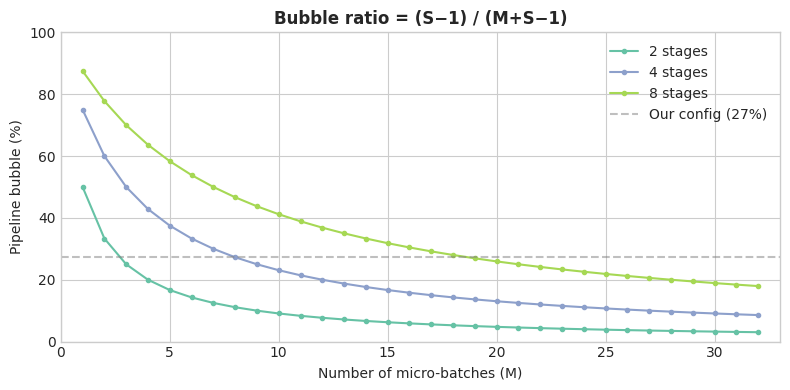

In [32]:
# Show how bubble ratio changes with number of micro-batches
fig, ax = plt.subplots(figsize=(8, 4))

stages_list = [2, 4, 8]
colors = plt.cm.Set2(np.linspace(0, 0.5, len(stages_list)))

for s, color in zip(stages_list, colors):
    ms = np.arange(1, 33)
    bubbles = (s - 1) / (ms + s - 1) * 100
    ax.plot(ms, bubbles, "o-", markersize=3, color=color, label=f"{s} stages")

ax.axhline(y=27.3, color="gray", linestyle="--", alpha=0.5, label="Our config (27%)")
ax.set_xlabel("Number of micro-batches (M)")
ax.set_ylabel("Pipeline bubble (%)")
ax.set_title("Bubble ratio = (S−1) / (M+S−1)", fontweight="bold")
ax.legend()
ax.set_ylim(0, 100)
ax.set_xlim(0, 33)
plt.tight_layout()
plt.show()

---

## Summary

Pipeline parallelism splits a deep model by layers across devices. The key ideas:

| Concept | Implementation | Purpose |
|---|---|---|
| **Stage** | `MLPLayers` on each device | Each device runs a subset of layers |
| **Micro-batching** | Split batch → scan over steps | Reduce pipeline bubble from $\frac{S-1}{S}$ to $\frac{S-1}{M+S-1}$ |
| **`ppermute`** | Ring $0 \to 1 \to \cdots \to S{-}1$ | Pass activations between consecutive stages |
| **`stack_params`** | `nn.Partitioned` wrapper | Annotate model-axis sharding |
| **`mask_except`** | Zero params on unused devices | Input/output layers on specific stages only |
| **`nn.map_variables`** | `ModelParallelismWrapper` | Transparent un/stacking so modules see normal arrays |

**When to use pipeline parallelism:**
- Model is too deep for a single device (many layers)
- Data parallelism forces batch sizes too small
- Communication is expensive relative to compute

**Limitations:**
- Pipeline bubble wastes some compute (mitigated by micro-batching)
- Requires balanced partitioning — uneven stages create bottlenecks
- Memory for activations grows with the number of micro-batches

In practice, pipeline parallelism is often **combined** with data parallelism (as we did here with a 2×4 mesh) and tensor parallelism for maximum scalability.